SHASHANK BHARAGANNARA GIRISWAMY

20022954

Programming assignment 1

In [69]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [70]:
# Step 1: Generate Random Data
# Define parameters for the distribution
mean = 0
std_dev = 1
n_points = 100

In [71]:
# Generate random data for x and y
# np.random.normal() generates random samples from a normal (Gaussian) distribution
# Parameters: mean, standard deviation, number of samples
x = np.random.normal(mean, std_dev, n_points)

# Define the true relationship
a =2  # slope
b =1  # intercept
epsilon = np.random.normal(0, 0.5, n_points)

# Generate y values based on the linear relationship with added noise
y= a*x+b+epsilon

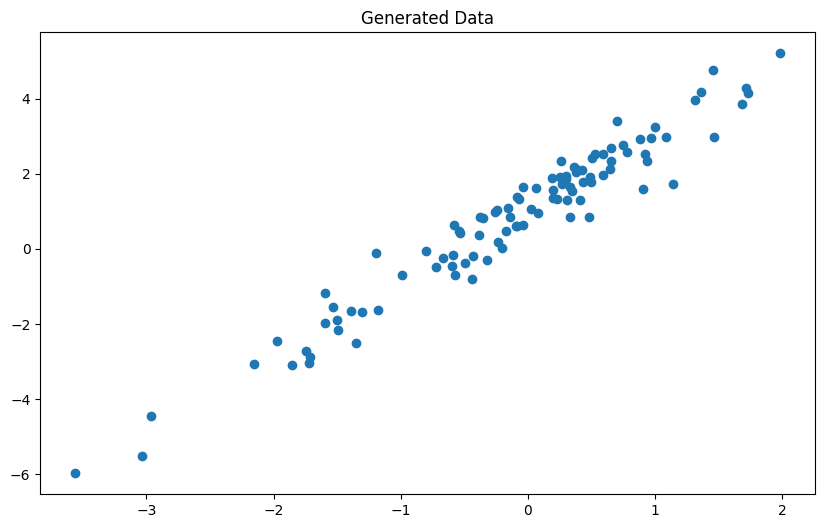

In [73]:
# Plot the generated data
plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.title("Generated Data")
plt.show()

Step 2: Perform Linear Regression Without Neural Networks

Here w ewill import Linear Regression 


In [74]:
# reshape x for the model scikit-learn because it expects 2D array 
x_reshaped = x.reshape(-1,1)

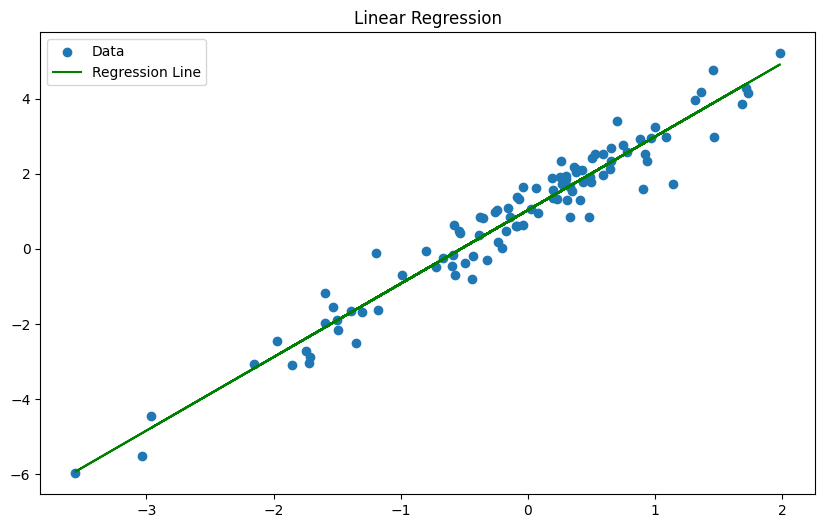

In [75]:
# LinearRegression() creates a linear regression model
# fit() method trains the model on the given data
linear_model=LinearRegression()
linear_model.fit(x_reshaped,y)

# Get the predicted y values
y_pred=linear_model.predict(x_reshaped)

# Plot the data and regression line
plt.figure(figsize=(10,6))
plt.scatter(x,y,label='Data')
plt.plot(x,y_pred,color='green',label='Regression Line')
plt.title('Linear Regression')
plt.legend()
plt.show()

Step 3: Linear Regression Using a Neural Network with Single Dense Layer

Now at this stage we need Sequential and Dense, that I will import from Ternsorflow. Keras

In [76]:
# Define the neural network model
# Sequential() creates a linear stack of layers
model = Sequential()
model.add(Dense(1,input_dim=1, activation='linear')) #here activation= linear means no activation function applied

c:\Users\Shashank B G\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [77]:
# Compiling the model
# loss='mean_squared_error' uses Mean Squared Error as the loss function
model.compile(optimizer='adam',loss='mean_squared_error')

In [78]:
# Train the model
# fit() trains the model for a fixed number of epochs 
model.fit(x,y,epochs=100, verbose=0)

In [79]:
# y_nn_pred gets the predicted y values from the neural network
y_nn_pred = model.predict(x)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


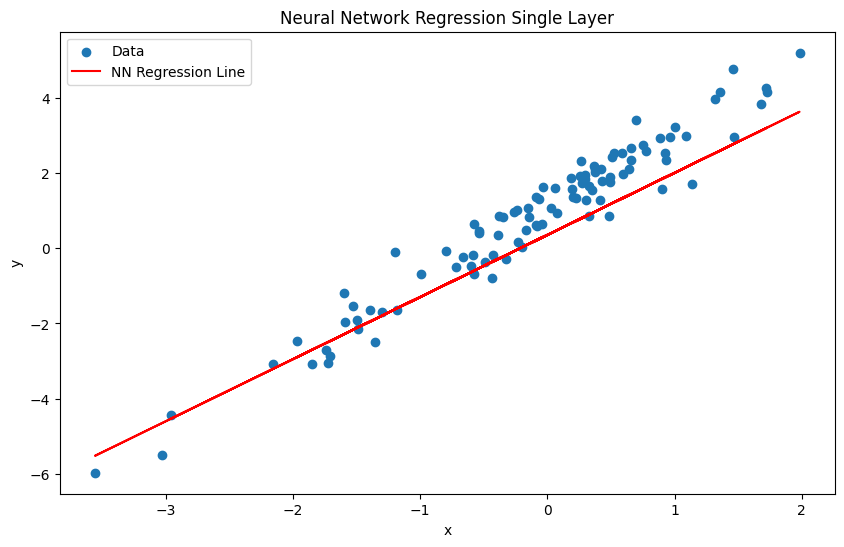

In [80]:
# Plotting the graph for data and networks regression line
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data')
plt.plot(x, y_nn_pred, color='red', label='NN Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Neural Network Regression Single Layer')
plt.legend()
plt.show()

Step 4: Experiment with Multiple Layers

In [81]:
# Function for to create and train a multi-layer neural network
def create_nn(layers):
    model = Sequential()
    model.add(Dense(64, input_dim=1, activation='relu'))
    for _ in range(layers - 2):
        model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(x, y, epochs=100, verbose=0)
    return model

In [87]:
# we can create any number of layers we want
models={
    '1-layer': model,  # We already created this
    '2-layer':create_nn(2),
    '3-layer':create_nn(3),
    '4-layer':create_nn(4),
}

c:\Users\Shashank B G\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


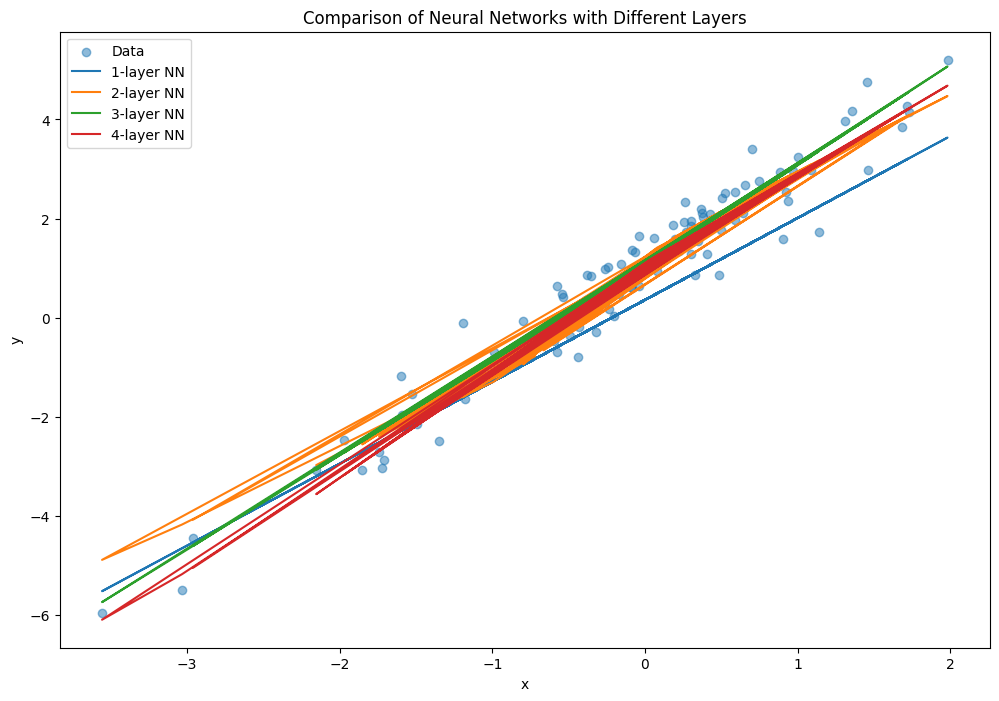

In [83]:
#prediction scatter plot for each model
plt.figure(figsize=(12, 8))
plt.scatter(x, y, label='Data', alpha=0.5)
for name, model in models.items():
    y_pred = model.predict(x)
    plt.plot(x, y_pred, label=f'{name} NN')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Neural Networks with Different Layers')
plt.legend()
plt.show()

Step 5: Compare and Visualize the Results

We will calculate and compare the Mean Squared Error for each model and plot the results.

In [85]:
from sklearn.metrics import mean_squared_error

In [86]:
mse_linear = mean_squared_error(y,y_pred)
mse_nn = {name:mean_squared_error(y,model.predict(x)) for name, model in models.items()}

# Print the results
print(f'MSE (Linear Regression): {mse_linear:.6f}')
for name, mse in mse_nn.items():
    print(f'MSE ({name} NN): {mse:.6f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MSE (Linear Regression): 0.251210
MSE (1-layer NN): 0.754275
MSE (2-layer NN): 0.302132
MSE (3-layer NN): 0.253477
MSE (4-layer NN): 0.251210



Explanation of results:

1. Linear Regression: This is our baseline model. It finds the best-fitting straight line through the data points.

2. Single Layer NN: This neural network should perform very similarly to linear regression, as it's essentially doing the same linear transformation.

3. Multi-layer NNs: As we add more layers, the network can potentially capture more complex relationships in the data. However, for this simple linear relationship, more layers might not necessarily improve performance and could lead to overfitting.